# Install Packages

# Imports

In [12]:
import os
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt

from zeroheliumkit import Structure, Rectangle, Square, Ring, Circle, Layer, GeomCollection  # type: ignore
from zeroheliumkit.src.importing import Reader_GDS,Reader_DXF,Reader_Pickle # type: ignore
from zeroheliumkit.fem import *
from zeroheliumkit.src.settings import  *
from zeroheliumkit.src.plotting import ColorHandler
import shapely

%matplotlib inline
%config InlineBackend.figure_format='retina'

plot_config = {'bottom':YELLOW2,'top':(BLUE,0.6),'wafer':BLACK}

# Device Importing

In [13]:
# Read File
file = Reader_GDS('TransferDevice_IDCs.gds')
device = GeomCollection(file.geometries)

# Rename Layers
device.rename('L1','bottom')
device.rename('L2','top')
device.rename('L3','wafer')

device.layers

TransferDevice_IDCs.gds // Layers in cell 'toplevel': [1, 2, 3]


['bottom', 'top', 'wafer']

# Viewing Electrodes

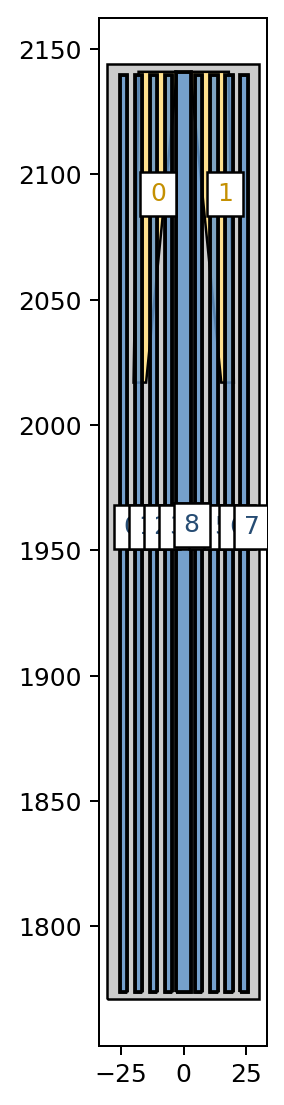

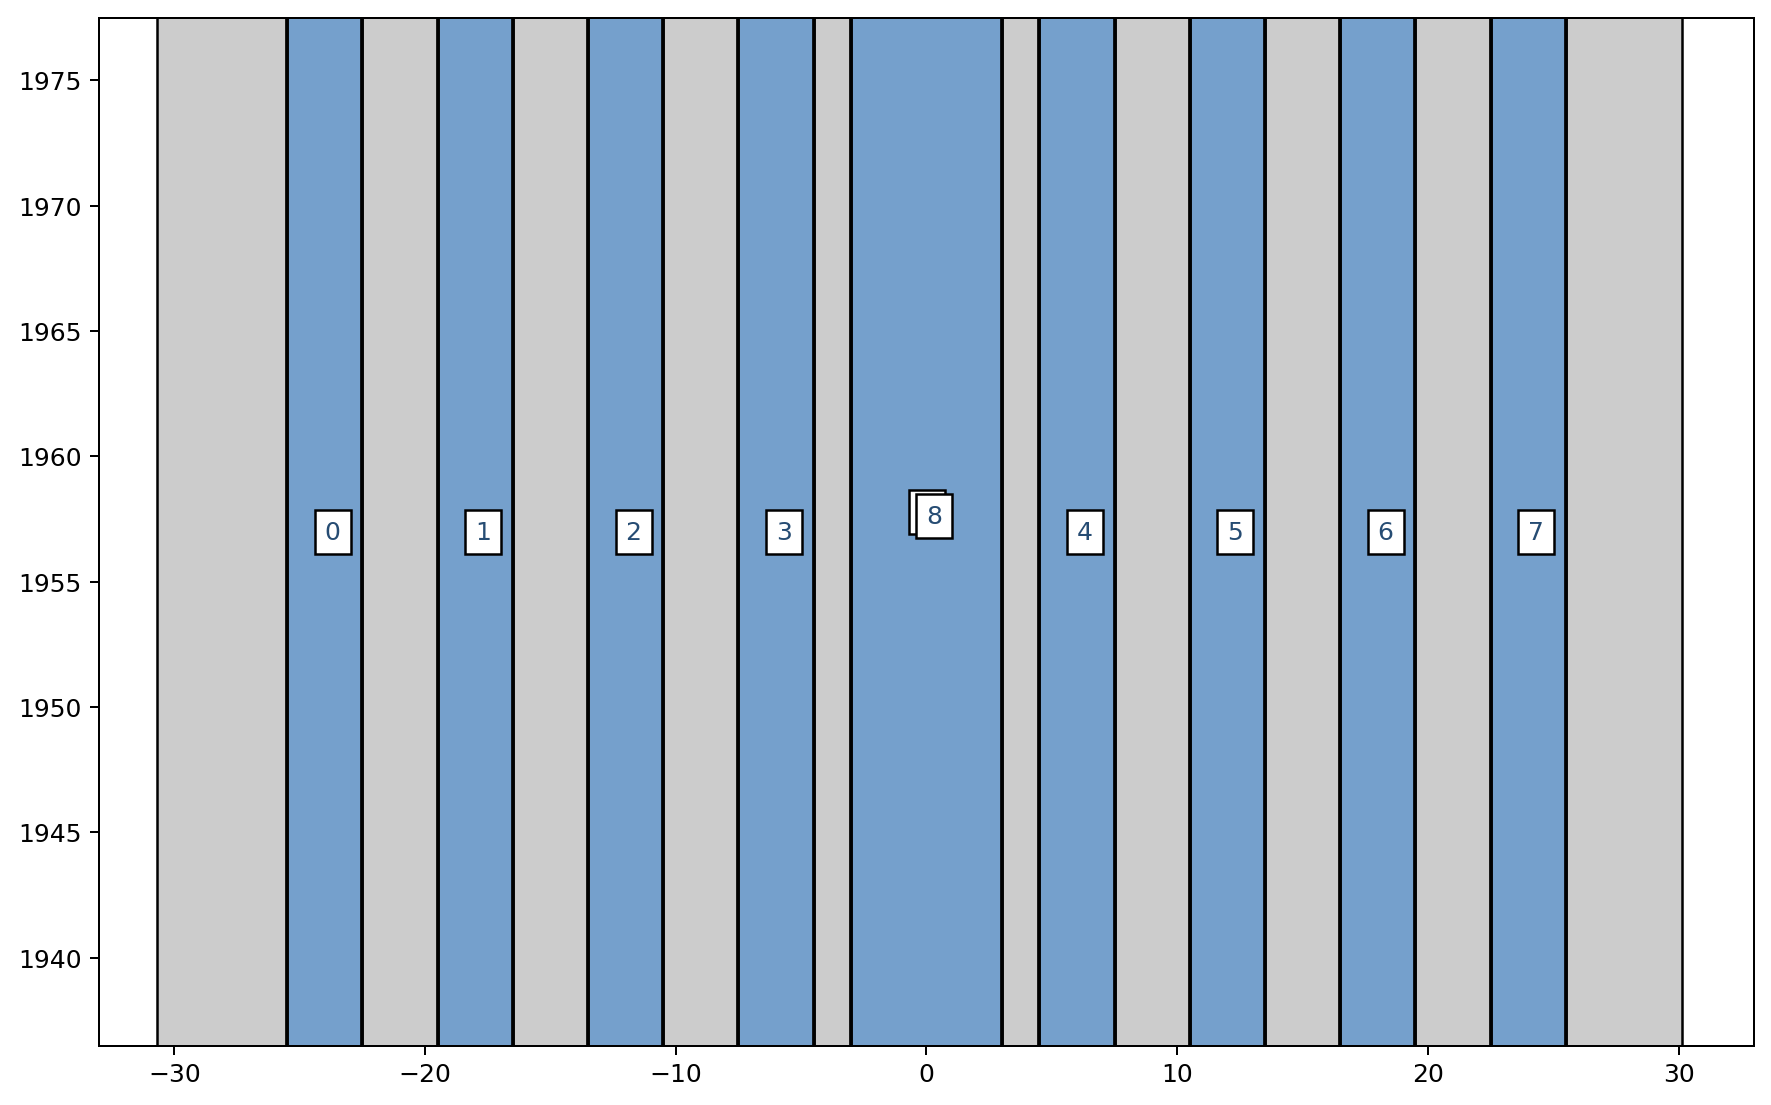

In [14]:
#Show Device
device.colors = ColorHandler({
    "wafer": GRAY,
    "top": YELLOW2,
    "bottom": (BLUE, 0.85)
})

device.quickplot(size='large',show_idx=True)
plt.show()
device.quickplot(size='large',show_idx=True,zoom = ((0,1957),1, 10))
plt.show()

# Define 3D Geometry

In [19]:
# defines thickness of layers [um]
d_metal1 = 0.25   # bottom metal thickness
d_metal2 = 0.25   # top metal thickness
d_diel  = 0.710
d_vac   = 25
d_He    = d_diel + d_metal2
d_total = d_metal1 + d_He

""" 
ExtrudeSettings
Args:
        geometry (Polygon | MultiPolygon): Geometry to be extruded.
        z (float): Z-coordinate or position of the layer.
        d (float): Thickness of the layer.
        physical_name (str): Physical name associated with the layer.
"""

Volumes = {
    'wafer' :       ExtrudeSettings(device.wafer.polygons, -d_vac/2 , d_vac/2         , 'DIELECTRIC'),
    'bottom':       ExtrudeSettings(device.bottom.polygons, 0 , d_metal1               , 'METAL'),
    'dielectric':   ExtrudeSettings(device.top.polygons, d_metal1 , d_diel          , 'DIELECTRIC'),
    'top':          ExtrudeSettings(device.top.polygons, d_metal1+d_diel, d_metal2  , 'METAL'),
    'helium':       ExtrudeSettings(device.wafer.polygons, d_metal1, d_He             , 'HELIUM', ('dielectric','top')),
    'vacuum':       ExtrudeSettings(device.wafer.polygons, d_metal1+d_He, d_vac       , 'VACUUM', ('dielectric', 'top'))
}

""" 
Settings for defining Perfect Electric Conductor (PEC) boundaries.

    Args:
        geometry (Polygon | MultiPolygon): Geometry of the PEC boundary.
        indices (list[int]): List of polygon indices associated with the PEC boundary.
        volume (str, optional): Volume identifier associated with the PEC boundary. Defaults to None.
"""

PECs = {
    'Barrier':      PECSettings(device.bottom.polygons,   [3,4], volume=Volumes['bottom']),
    'ThinFilm':     PECSettings(device.bottom.polygons,   [8],   volume=Volumes['bottom']),
    'IDC+':         PECSettings(device.bottom.polygons,   [1,6],   volume=Volumes['bottom']),
    'IDC-':         PECSettings(device.bottom.polygons,   [0,2,5,7],   volume=Volumes['bottom']),
    'Top':          PECSettings(device.top.polygons,      [0,1], volume=Volumes['top']),
}

In [20]:

""" 
mesh_params is a list of dicts.
Each dict is for a different density region (here fine and medium) given of the form:
Thickness : width (in um) of the transition from this region's density to the outer layers density,
VIn       : density scale inside the region
VOut      : density scale outside the region
box       : coordinates of the boundary given as [x0,x1,y0,y1,z0,z1]
"""
scale = 4
mediumregion_box = [-30, 30, 1800, 2125, -0.7, 6]
fineregion_box = [-10, 10, 1950, 2125, -0.1, 4.5]

mesh = MeshSettings(
    dim = 3,
    fields = {
        "Box": [BoxFieldMeshSettings(Thickness=4, VIn=scale * 0.4, VOut=scale * 1, box=mediumregion_box),
                BoxFieldMeshSettings(Thickness=2, VIn=scale * 0.2, VOut=scale * 1, box=fineregion_box)]
    }
)

# Generate Mesh

In [21]:
save_dir = "dump"
meshMKR = GMSHmaker(
    extrude = Volumes,
    surfaces = None,
    pecs = PECs,
    mesh = mesh,
    save = {"dir": save_dir, "filename": "dot"},
    open_gmsh = True,
    debug_mode = False
)

on 0: mesh is constructed                                                       
on 0: mesh saved                                                                
Gmsh generation  |███| 1/1 [100%] in 18.1s (0.06/s)                             


# Create edp file

In [22]:
from zeroheliumkit.fem.freefemer import FFconfigurator, ExtractConfig, FreeFEM

In [23]:
var_eps = {
        'DIELECTRIC': 11.0,
        'METAL': 1.0,
        'HELIUM': 1.057,
        'VACUUM': 1.0,
}

""""
ExtractConfig() function
Args:
        name (str): The name of the extract config; acts as a label for the data configuration.
        quantity (str): The quantity to be extracted (e.g., 'phi', 'Ex', 'Ey', 'Ez', 'Cm').
        plane (str): The plane for extraction (e.g., 'xy', 'yz', 'xz', 'xyZ').
        coordinate1 (tuple): A tuple containing the start and end coordinates and the number of points for the first coordinate.
        coordinate2 (tuple): A tuple containing the start and end coordinates and the number of points for the second coordinate.
        coordinate3 (float | list | dict): User can input a float, list, or dictionary depending on their desired configuration. All inputs are converted to a list.
"""

ffc = FFconfigurator(config_file="dump/dot.yaml",
                     dielectric_constants=var_eps,
                     ff_polynomial=2,
                     extract_opt=[ExtractConfig("result1", 'phi', 'xy', (-10,10,201), (1950,2125,201), d_He)],
                     msh_refinements=None
                     )

In [24]:
pyff = FreeFEM(config_file="dump/dot.yaml")

In [25]:
await pyff.run(cores=4, print_log=True, remove=True) 

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_Barrier.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_ThinFilm.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_IDC+.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_IDC-.edp', layout=Layout(margin='4px 0'))

-- FreeFem++ v4.6 (Fri, Apr 03, 2020  2:08:08 PM - git v4.6)
 Load: lg_fem lg_mesh lg_mesh3 eigenvalue 
'ffglut.exe' is not recognized as an internal or external command,
operable program or batch file.
(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\msh3 = 0)(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\gmsh = 0)(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\medit = 0)(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\mshmet = 0) load: mshmet  
(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\tetgen = 0) load: tetgen  
 sizestack + 1024 =3512  ( 2488 )

598461 tetrahedrons
47492 triangles
645953 numElements
  -- Build Nodes/DF on mesh :   n.v. 108256, n. elmt. 598461, n b. elmt. 47492
     nb of Nodes 842230    nb of DoF   842230  DFon=1100
  -- FESpace: Nb of Nodes 842230 Nb of DoF 842230
  -- Build Nodes/DF on mesh :   n.v. 108256, n. elmt. 598461, n b. elmt. 47492
     nb of Nodes 598461    nb of DoF   598461  DFon=0001
  -- FESpace: Nb of Nodes 598461 

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_Top.edp', layout=Layout(margin='4px 0'))

-- FreeFem++ v4.6 (Fri, Apr 03, 2020  2:08:08 PM - git v4.6)
 Load: lg_fem lg_mesh lg_mesh3 eigenvalue 
'ffglut.exe' is not recognized as an internal or external command,
operable program or batch file.
(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\msh3 = 0)(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\gmsh = 0)(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\medit = 0)(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\mshmet = 0) load: mshmet  
(load: loadLibary C:\Program Files (x86)\FreeFem++\\.\tetgen = 0) load: tetgen  
 sizestack + 1024 =3512  ( 2488 )

598461 tetrahedrons
47492 triangles
645953 numElements
  -- Build Nodes/DF on mesh :   n.v. 108256, n. elmt. 598461, n b. elmt. 47492
     nb of Nodes 842230    nb of DoF   842230  DFon=1100
  -- FESpace: Nb of Nodes 842230 Nb of DoF 842230
  -- Build Nodes/DF on mesh :   n.v. 108256, n. elmt. 598461, n b. elmt. 47492
     nb of Nodes 598461    nb of DoF   598461  DFon=0001
  -- FESpace: Nb of Nodes 598461 